In [3]:
# ============================================================
# CreatorIQ — Exploratory Data Analysis
# Module 3: Understanding our creator marketing data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual style for all charts
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Hardcoded absolute path — works regardless of where notebook runs from
DATA_DIR = r"C:\Users\vinni\creatoriq\data"

creators          = pd.read_csv(os.path.join(DATA_DIR, "creators.csv"))
campaigns         = pd.read_csv(os.path.join(DATA_DIR, "campaigns.csv"))
campaign_creators = pd.read_csv(os.path.join(DATA_DIR, "campaign_creators.csv"))
posts             = pd.read_csv(os.path.join(DATA_DIR, "posts.csv"))
conversions       = pd.read_csv(os.path.join(DATA_DIR, "conversions.csv"))

print("All datasets loaded successfully!")
print()
print(f"creators:          {creators.shape}")
print(f"campaigns:         {campaigns.shape}")
print(f"campaign_creators: {campaign_creators.shape}")
print(f"posts:             {posts.shape}")
print(f"conversions:       {conversions.shape}")

All datasets loaded successfully!

creators:          (200, 11)
campaigns:         (70, 8)
campaign_creators: (460, 8)
posts:             (783, 12)
conversions:       (2437, 10)


In [4]:
# ============================================================
# STEP 1: SHAPE & DATA QUALITY CHECK
# First thing every analyst does — understand what you have
# ============================================================

print("=" * 55)
print("CREATORS TABLE — Basic Info")
print("=" * 55)
print(creators.info())
print()

print("=" * 55)
print("MISSING VALUES across all tables")
print("=" * 55)
print("creators nulls:")
print(creators.isnull().sum())
print()
print("posts nulls:")
print(posts.isnull().sum())
print()
print("conversions nulls:")
print(conversions.isnull().sum())
print()

print("=" * 55)
print("CREATORS — First 5 rows")
print("=" * 55)
print(creators.head())

CREATORS TABLE — Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   creator_id                   200 non-null    int64  
 1   name                         200 non-null    object 
 2   handle                       200 non-null    object 
 3   platform                     200 non-null    object 
 4   niche                        200 non-null    object 
 5   tier                         200 non-null    object 
 6   follower_count               200 non-null    int64  
 7   avg_engagement_rate          200 non-null    float64
 8   country                      200 non-null    object 
 9   audience_authenticity_score  0 non-null      float64
 10  joined_date                  200 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 17.3+ KB
None

MISSING VALUES across all tables
creators nu

TIER DISTRIBUTION — How many creators per tier?
tier
nano     103
micro     56
macro     31
mega      10
Name: count, dtype: int64

ENGAGEMENT RATE BY TIER
Should DECREASE as tier size increases
(nano highest, mega lowest)
       count avg_followers  avg_engagement  min_engagement  max_engagement
tier                                                                      
nano     103         5,812            8.18            6.01           10.00
micro     56        58,187            4.46            3.01            6.00
macro     31       575,167            1.90            1.04            2.93
mega      10     2,951,633            1.06            0.53            1.45



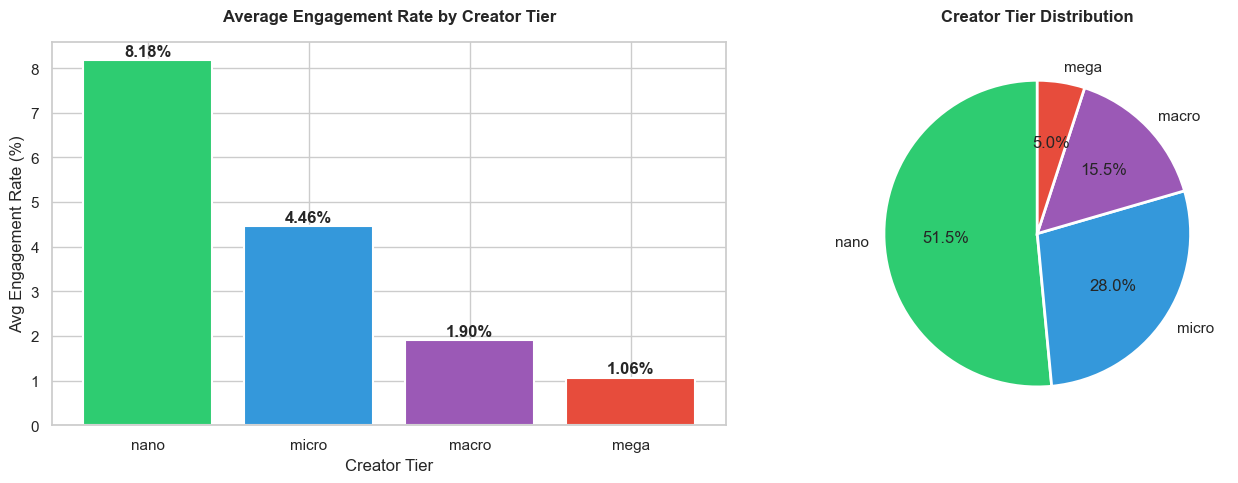

Chart saved.


In [5]:
# ============================================================
# STEP 2: CREATOR TIER ANALYSIS
# The inverse engagement-follower relationship
# This is the first real business insight of the project
# ============================================================

print("=" * 55)
print("TIER DISTRIBUTION — How many creators per tier?")
print("=" * 55)
tier_counts = creators['tier'].value_counts()
print(tier_counts)
print()

print("=" * 55)
print("ENGAGEMENT RATE BY TIER")
print("Should DECREASE as tier size increases")
print("(nano highest, mega lowest)")
print("=" * 55)
tier_engagement = creators.groupby('tier').agg(
    count=('creator_id', 'count'),
    avg_followers=('follower_count', 'mean'),
    avg_engagement=('avg_engagement_rate', 'mean'),
    min_engagement=('avg_engagement_rate', 'min'),
    max_engagement=('avg_engagement_rate', 'max')
).reindex(['nano', 'micro', 'macro', 'mega'])

tier_engagement['avg_followers'] = tier_engagement['avg_followers'].apply(lambda x: f"{x:,.0f}")
tier_engagement['avg_engagement'] = tier_engagement['avg_engagement'].round(2)
print(tier_engagement)
print()

# ---- CHART 1: Engagement rate by tier ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — average engagement rate by tier
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
tier_order = ['nano', 'micro', 'macro', 'mega']
avg_er = [creators[creators['tier']==t]['avg_engagement_rate'].mean() for t in tier_order]

axes[0].bar(tier_order, avg_er, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Average Engagement Rate by Creator Tier', fontweight='bold', pad=15)
axes[0].set_xlabel('Creator Tier')
axes[0].set_ylabel('Avg Engagement Rate (%)')
for i, v in enumerate(avg_er):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# Pie chart — tier distribution
axes[1].pie(tier_counts.values,
            labels=tier_counts.index,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Creator Tier Distribution', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(r"C:\Users\vinni\creatoriq\notebooks\chart_01_tier_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

ENGAGEMENT RATE vs CONVERSION RATE by tier
Key question: does high engagement = high sales?
       avg_engagement_rate  avg_conversion_rate  total_posts
tier                                                        
nano                 8.119                0.058          412
micro                4.406                2.987          209
macro                1.897                2.174          131
mega                 1.071                2.591           31



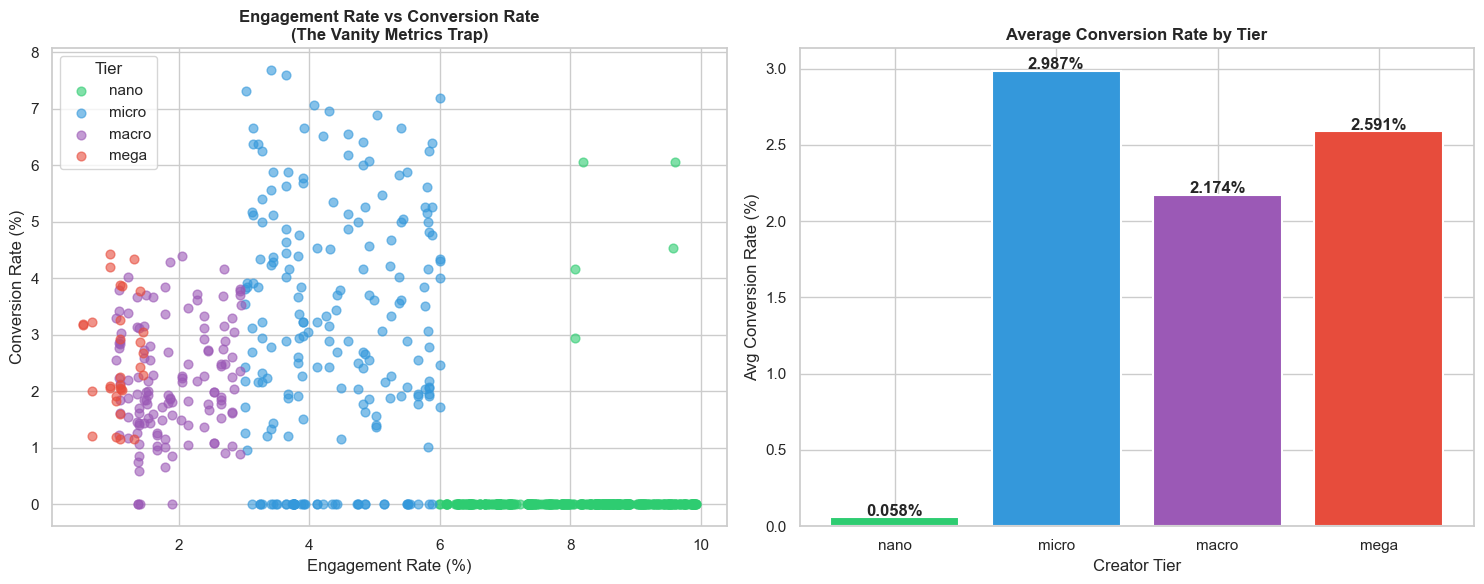

Chart saved.


In [6]:
# ============================================================
# STEP 3: THE VANITY METRICS TRAP
# The core insight of CreatorIQ —
# High engagement does NOT equal high sales
# ============================================================

# Calculate engagement rate per post
posts['engagement_rate'] = (
    (posts['likes'] + posts['comments'] + posts['shares'])
    / posts['reach'].replace(0, np.nan)
) * 100

# Calculate conversion rate per post
conv_counts = conversions.groupby('post_id').size().reset_index(name='num_conversions')
posts_merged = posts.merge(conv_counts, on='post_id', how='left')
posts_merged['num_conversions'] = posts_merged['num_conversions'].fillna(0)
posts_merged['conversion_rate'] = (
    posts_merged['num_conversions'] /
    posts_merged['clicks'].replace(0, np.nan)
) * 100

# Merge with creator tier
posts_full = posts_merged.merge(
    creators[['creator_id', 'tier', 'niche', 'platform']],
    on='creator_id', how='left'
)

print("=" * 55)
print("ENGAGEMENT RATE vs CONVERSION RATE by tier")
print("Key question: does high engagement = high sales?")
print("=" * 55)
summary = posts_full.groupby('tier').agg(
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_conversion_rate=('conversion_rate', 'mean'),
    total_posts=('post_id', 'count')
).reindex(['nano', 'micro', 'macro', 'mega']).round(3)
print(summary)
print()

# ---- CHART 2: Engagement vs Conversion scatter ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot — engagement rate vs conversion rate
colors_map = {'nano': '#2ecc71', 'micro': '#3498db',
              'macro': '#9b59b6', 'mega': '#e74c3c'}
for tier in ['nano', 'micro', 'macro', 'mega']:
    subset = posts_full[posts_full['tier'] == tier]
    axes[0].scatter(
        subset['engagement_rate'],
        subset['conversion_rate'],
        label=tier,
        color=colors_map[tier],
        alpha=0.6,
        s=40
    )
axes[0].set_title('Engagement Rate vs Conversion Rate\n(The Vanity Metrics Trap)',
                   fontweight='bold')
axes[0].set_xlabel('Engagement Rate (%)')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].legend(title='Tier')

# Bar chart — avg conversion rate by tier
tiers = ['nano', 'micro', 'macro', 'mega']
cvr_vals = [summary.loc[t, 'avg_conversion_rate'] for t in tiers]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = axes[1].bar(tiers, cvr_vals, color=colors,
                    edgecolor='white', linewidth=1.5)
axes[1].set_title('Average Conversion Rate by Tier',
                   fontweight='bold')
axes[1].set_xlabel('Creator Tier')
axes[1].set_ylabel('Avg Conversion Rate (%)')
for bar, val in zip(bars, cvr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.01,
                  f'{val:.3f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\vinni\creatoriq\notebooks\chart_02_vanity_metrics.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

PLATFORM PERFORMANCE
           avg_engagement_rate   avg_reach  avg_clicks  total_posts
platform                                                           
twitter                  6.141   38544.000      64.459          257
youtube                  6.069   80671.424     134.085          165
tiktok                   5.763  153539.023     192.110          219
instagram                4.970   83504.261     121.754          142

CONTENT FORMAT PERFORMANCE
                avg_engagement_rate  avg_clicks  total_posts
content_format                                              
video                         6.084     124.708          130
reel                          5.942     108.893          122
carousel                      5.793     103.463          147
story                         5.773     157.014          138
image                         5.734     119.616          138
short                         5.482     140.463          108



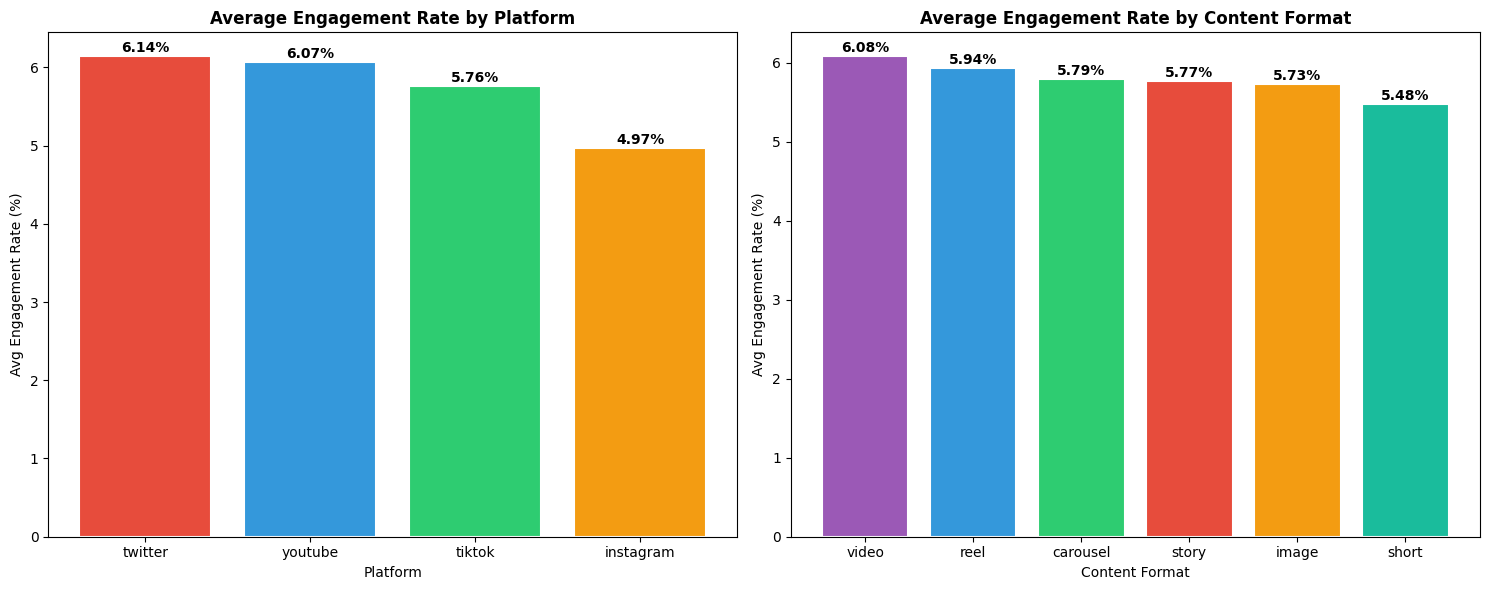

Chart 3 saved successfully.


In [2]:
# ============================================================
# STEP 4: PLATFORM & CONTENT FORMAT PERFORMANCE
# Self-contained cell — loads its own data, no dependencies
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Define paths directly in this cell
DATA_DIR   = r"C:\Users\vinni\creatoriq\data"
CHARTS_DIR = r"C:\Users\vinni\creatoriq\notebooks"

# Load posts directly — no dependency on Cell 1
posts2 = pd.read_csv(os.path.join(DATA_DIR, "posts.csv"))

# Calculate engagement rate
posts2['engagement_rate'] = (
    (posts2['likes'] + posts2['comments'] + posts2['shares'])
    / posts2['reach'].replace(0, np.nan)
) * 100

# Platform stats
platform_stats = posts2.groupby('platform').agg(
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_reach=('reach', 'mean'),
    avg_clicks=('clicks', 'mean'),
    total_posts=('post_id', 'count')
).round(3)

print("=" * 55)
print("PLATFORM PERFORMANCE")
print("=" * 55)
print(platform_stats.sort_values('avg_engagement_rate', ascending=False))
print()

# Content format stats
format_stats = posts2.groupby('content_format').agg(
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_clicks=('clicks', 'mean'),
    total_posts=('post_id', 'count')
).round(3)

print("=" * 55)
print("CONTENT FORMAT PERFORMANCE")
print("=" * 55)
print(format_stats.sort_values('avg_engagement_rate', ascending=False))
print()

# Chart 3: Platform and format
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

platform_er = platform_stats['avg_engagement_rate'].sort_values(ascending=False)
colors_p    = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
axes[0].bar(platform_er.index, platform_er.values,
            color=colors_p, edgecolor='white', linewidth=1.5)
axes[0].set_title('Average Engagement Rate by Platform',
                   fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Avg Engagement Rate (%)')
for i, v in enumerate(platform_er.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}%',
                  ha='center', fontweight='bold')

format_er = format_stats['avg_engagement_rate'].sort_values(ascending=False)
colors_f  = ['#9b59b6', '#3498db', '#2ecc71',
             '#e74c3c', '#f39c12', '#1abc9c']
axes[1].bar(format_er.index, format_er.values,
            color=colors_f, edgecolor='white', linewidth=1.5)
axes[1].set_title('Average Engagement Rate by Content Format',
                   fontweight='bold')
axes[1].set_xlabel('Content Format')
axes[1].set_ylabel('Avg Engagement Rate (%)')
for i, v in enumerate(format_er.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}%',
                  ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart_03_platform_format.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved successfully.")

ROI BY CREATOR TIER
         avg_fee  avg_revenue  avg_roi_pct  total_partnerships
tier                                                          
nano      287.34       709.46       149.22                 221
micro    2941.99      7473.90       149.21                 146
macro   29418.82     75116.65       159.19                  71
mega   338028.93    750472.36       108.86                  22

TOP 10 CREATORS BY ROI
                  avg_roi  total_revenue  total_fee
name                                               
Thomas Robles      688.24       33109.79    4200.49
Nicole Becker      536.46        4393.71     706.69
Gary Gonzalez      525.74      313441.48   48281.37
Denise Parks       467.38        3094.61     715.47
Victoria Lin       418.69        2687.74     540.78
Robin Schultz      417.97        5328.53    1120.30
Paige Moses        403.79        1650.10     274.86
Christian Harris   393.42      423634.79   74558.79
Marvin Collins     372.11        4277.48     910.81
Henry 

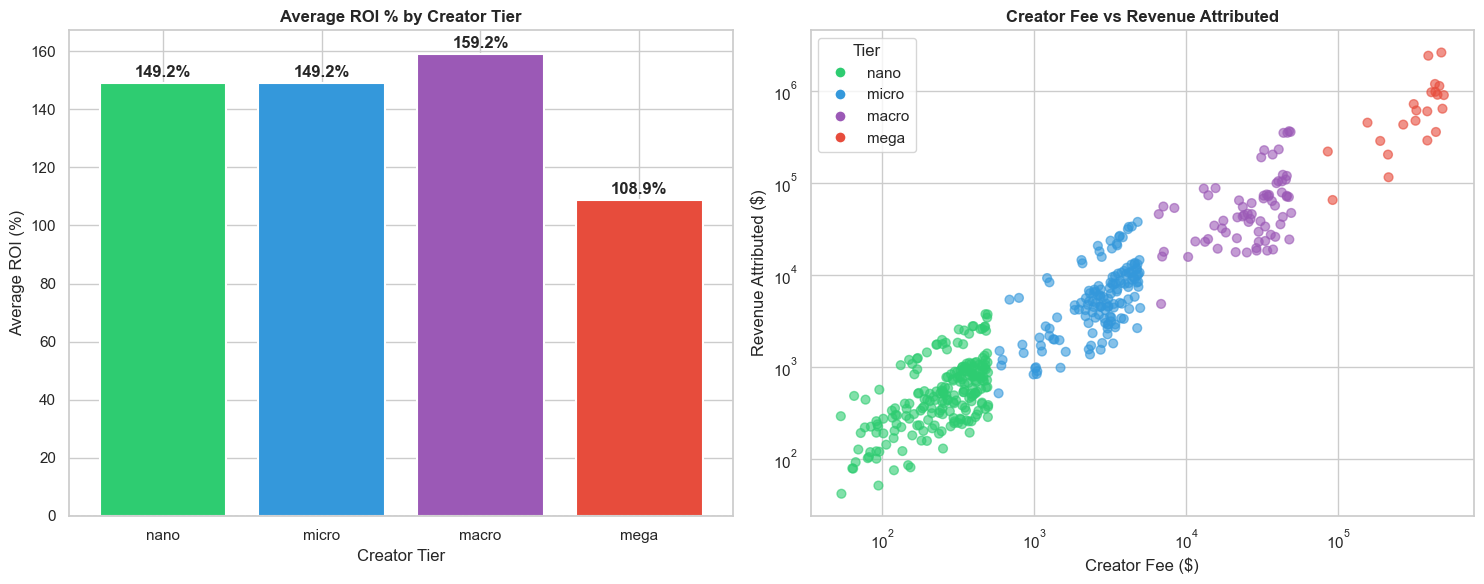

Chart 4 saved.


In [11]:
# ============================================================
# STEP 5: ROI ANALYSIS
# ============================================================

CHARTS_DIR = r"C:\Users\vinni\creatoriq\notebooks"

cc_full = campaign_creators.merge(
    creators[['creator_id', 'tier', 'niche', 'platform']],
    on='creator_id', how='left'
)

cc_full['roi_pct'] = (
    (cc_full['revenue_attributed'] - cc_full['creator_fee'])
    / cc_full['creator_fee'].replace(0, np.nan)
) * 100

print("=" * 55)
print("ROI BY CREATOR TIER")
print("=" * 55)
roi_by_tier = cc_full.groupby('tier').agg(
    avg_fee=('creator_fee', 'mean'),
    avg_revenue=('revenue_attributed', 'mean'),
    avg_roi_pct=('roi_pct', 'mean'),
    total_partnerships=('cc_id', 'count')
).reindex(['nano', 'micro', 'macro', 'mega']).round(2)
print(roi_by_tier)
print()

print("=" * 55)
print("TOP 10 CREATORS BY ROI")
print("=" * 55)
top_creators = cc_full.merge(
    creators[['creator_id', 'name']], on='creator_id', how='left'
)
top_10 = top_creators.groupby('name').agg(
    avg_roi=('roi_pct', 'mean'),
    total_revenue=('revenue_attributed', 'sum'),
    total_fee=('creator_fee', 'sum')
).sort_values('avg_roi', ascending=False).head(10).round(2)
print(top_10)
print()

# Chart 4: ROI analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors   = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
tiers    = ['nano', 'micro', 'macro', 'mega']
roi_vals = [roi_by_tier.loc[t, 'avg_roi_pct'] for t in tiers]

axes[0].bar(tiers, roi_vals, color=colors,
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Average ROI % by Creator Tier', fontweight='bold')
axes[0].set_xlabel('Creator Tier')
axes[0].set_ylabel('Average ROI (%)')
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(roi_vals):
    axes[0].text(i, v + 2, f'{v:.1f}%',
                  ha='center', fontweight='bold')

axes[1].scatter(
    cc_full['creator_fee'],
    cc_full['revenue_attributed'],
    c=cc_full['tier'].map({
        'nano': '#2ecc71', 'micro': '#3498db',
        'macro': '#9b59b6', 'mega': '#e74c3c'
    }),
    alpha=0.6, s=40
)
axes[1].set_title('Creator Fee vs Revenue Attributed', fontweight='bold')
axes[1].set_xlabel('Creator Fee ($)')
axes[1].set_ylabel('Revenue Attributed ($)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=c, markersize=8, label=t)
    for t, c in [('nano','#2ecc71'), ('micro','#3498db'),
                 ('macro','#9b59b6'), ('mega','#e74c3c')]
]
axes[1].legend(handles=legend_elements, title='Tier')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart_04_roi_analysis.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

TOTAL REVENUE SUMMARY
Total revenue generated:  $160,830.47
Total conversions:        2,437
Average order value:      $66.00

REVENUE BY DEVICE TYPE
                   sum   mean  count
device_type                         
desktop       32055.34  63.10    508
mobile       114664.94  66.43   1726
tablet        14110.19  69.51    203

REVENUE BY AGE GROUP
                sum   mean  count
age_group                        
35-44      28660.42  67.44    425
13-17      28449.16  69.05    412
55+        27779.01  64.30    432
18-24      26009.45  64.06    406
45-54      25752.46  65.70    392
25-34      24179.97  65.35    370



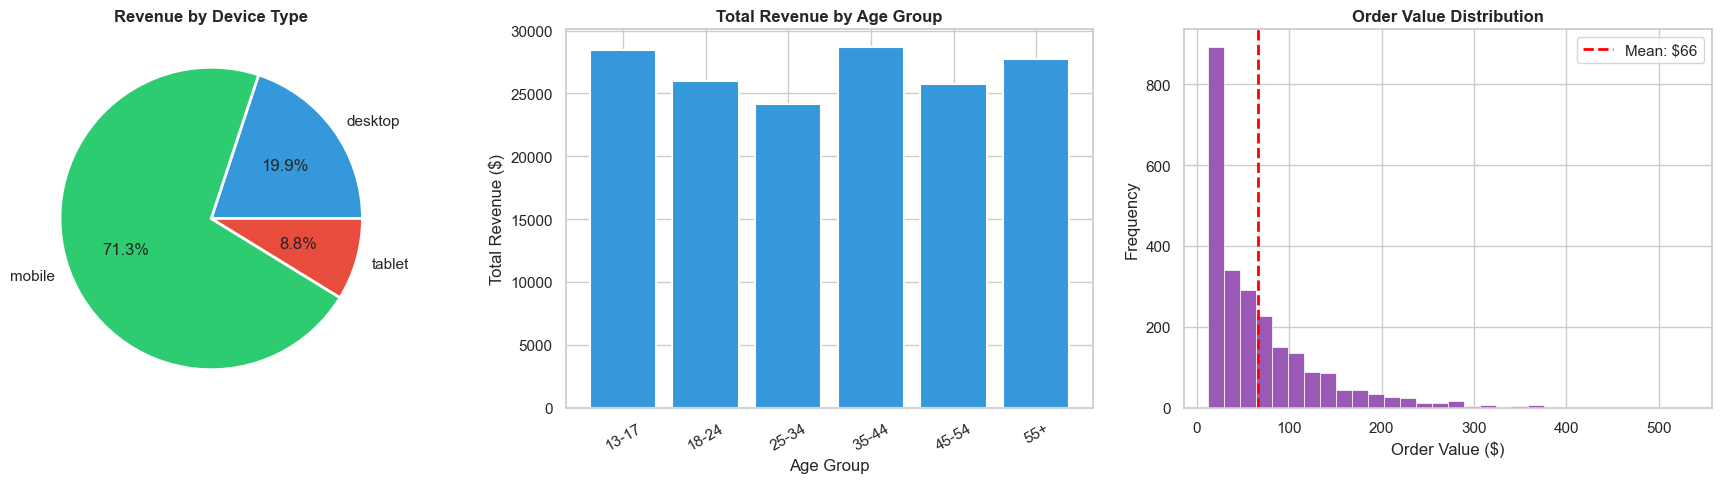

Chart 5 saved.


In [13]:
# ============================================================
# STEP 6: REVENUE & CONVERSION SUMMARY
# ============================================================

CHARTS_DIR = r"C:\Users\vinni\creatoriq\notebooks"

print("=" * 55)
print("TOTAL REVENUE SUMMARY")
print("=" * 55)
total_revenue = conversions['order_value'].sum()
avg_order     = conversions['order_value'].mean()
total_orders  = len(conversions)
print(f"Total revenue generated:  ${total_revenue:,.2f}")
print(f"Total conversions:        {total_orders:,}")
print(f"Average order value:      ${avg_order:.2f}")
print()

print("=" * 55)
print("REVENUE BY DEVICE TYPE")
print("=" * 55)
print(conversions.groupby('device_type')['order_value'].agg(
    ['sum', 'mean', 'count']
).round(2))
print()

print("=" * 55)
print("REVENUE BY AGE GROUP")
print("=" * 55)
print(conversions.groupby('age_group')['order_value'].agg(
    ['sum', 'mean', 'count']
).round(2).sort_values('sum', ascending=False))
print()

# Chart 5: Revenue breakdown
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Device breakdown
device_rev = conversions.groupby('device_type')['order_value'].sum()
axes[0].pie(device_rev.values,
            labels=device_rev.index,
            autopct='%1.1f%%',
            colors=['#3498db', '#2ecc71', '#e74c3c'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Revenue by Device Type', fontweight='bold')

# Age group revenue
age_rev = conversions.groupby('age_group')['order_value'].sum()
age_rev = age_rev.reindex(
    ['13-17', '18-24', '25-34', '35-44', '45-54', '55+']
)
axes[1].bar(age_rev.index, age_rev.values,
            color='#3498db', edgecolor='white', linewidth=1.5)
axes[1].set_title('Total Revenue by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].tick_params(axis='x', rotation=30)

# Order value distribution
axes[2].hist(conversions['order_value'], bins=30,
             color='#9b59b6', edgecolor='white', linewidth=0.5)
axes[2].set_title('Order Value Distribution', fontweight='bold')
axes[2].set_xlabel('Order Value ($)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(avg_order, color='red', linestyle='--',
                linewidth=2, label=f'Mean: ${avg_order:.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart_05_revenue_summary.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

In [14]:
# ============================================================
# STEP 7: KEY INSIGHTS SUMMARY
# What this EDA tells a brand manager
# ============================================================

print("=" * 55)
print("CREATORIQ EDA — KEY INSIGHTS SUMMARY")
print("=" * 55)
print()

# Tier engagement
nano_er  = creators[creators['tier']=='nano']['avg_engagement_rate'].mean()
mega_er  = creators[creators['tier']=='mega']['avg_engagement_rate'].mean()

# Recalculate summary if not available
posts_temp = posts.copy()
posts_temp['engagement_rate'] = (
    (posts_temp['likes'] + posts_temp['comments'] + posts_temp['shares'])
    / posts_temp['reach'].replace(0, np.nan)
) * 100

conv_counts_temp = conversions.groupby('post_id').size().reset_index(
    name='num_conversions'
)
posts_temp = posts_temp.merge(conv_counts_temp, on='post_id', how='left')
posts_temp['num_conversions'] = posts_temp['num_conversions'].fillna(0)
posts_temp['conversion_rate'] = (
    posts_temp['num_conversions'] /
    posts_temp['clicks'].replace(0, np.nan)
) * 100
posts_temp = posts_temp.merge(
    creators[['creator_id', 'tier']], on='creator_id', how='left'
)

summary_temp = posts_temp.groupby('tier').agg(
    avg_conversion_rate=('conversion_rate', 'mean')
).reindex(['nano', 'micro', 'macro', 'mega']).round(3)

nano_cvr = summary_temp.loc['nano', 'avg_conversion_rate']
mega_cvr = summary_temp.loc['mega', 'avg_conversion_rate']

# Platform best
posts2_temp = posts.copy()
posts2_temp['engagement_rate'] = (
    (posts2_temp['likes'] + posts2_temp['comments'] + posts2_temp['shares'])
    / posts2_temp['reach'].replace(0, np.nan)
) * 100
platform_temp = posts2_temp.groupby('platform')['engagement_rate'].mean()
format_temp   = posts2_temp.groupby('content_format')['engagement_rate'].mean()

best_platform = platform_temp.idxmax()
best_er       = platform_temp.max()
best_format   = format_temp.idxmax()
best_fer      = format_temp.max()

total_revenue = conversions['order_value'].sum()
avg_order     = conversions['order_value'].mean()
total_orders  = len(conversions)

print(f"INSIGHT 1 — The Inverse Engagement Rule:")
print(f"  Nano creators engage at {nano_er:.1f}%")
print(f"  Mega creators engage at {mega_er:.1f}%")
print(f"  Nano creators are {nano_er/mega_er:.0f}x better at engagement")
print()

print(f"INSIGHT 2 — The Vanity Metrics Trap:")
print(f"  Nano CVR:  {nano_cvr:.3f}%")
print(f"  Mega CVR:  {mega_cvr:.3f}%")
if nano_cvr > 0:
    print(f"  Mega creators convert {mega_cvr/nano_cvr:.0f}x better")
    print(f"  despite having {nano_er/mega_er:.0f}x lower engagement")
print()

print(f"INSIGHT 3 — Best Platform:")
print(f"  {best_platform.title()} leads at {best_er:.2f}% avg engagement")
print()

print(f"INSIGHT 4 — Best Content Format:")
print(f"  {best_format.title()} performs best at {best_fer:.2f}%")
print()

print(f"INSIGHT 5 — Revenue Generated:")
print(f"  Total:         ${total_revenue:,.2f}")
print(f"  Conversions:   {total_orders:,}")
print(f"  Avg order:     ${avg_order:.2f}")
print()

print("=" * 55)
print("EDA COMPLETE — Ready for AI model in Module 5")
print("=" * 55)

CREATORIQ EDA — KEY INSIGHTS SUMMARY

INSIGHT 1 — The Inverse Engagement Rule:
  Nano creators engage at 8.2%
  Mega creators engage at 1.1%
  Nano creators are 8x better at engagement

INSIGHT 2 — The Vanity Metrics Trap:
  Nano CVR:  0.058%
  Mega CVR:  2.591%
  Mega creators convert 45x better
  despite having 8x lower engagement

INSIGHT 3 — Best Platform:
  Twitter leads at 6.14% avg engagement

INSIGHT 4 — Best Content Format:
  Video performs best at 6.08%

INSIGHT 5 — Revenue Generated:
  Total:         $160,830.47
  Conversions:   2,437
  Avg order:     $66.00

EDA COMPLETE — Ready for AI model in Module 5
